## 5.2 합성곱 신경망 맛보기
fashion_mnist 데이터셋을 사용하여 합성곱 신경망을 직접 구현해본다.
- fashion_mnist 데이터셋: 토치비전에 내장된 예제 데이터로 운동화, 셔츠, 샌들 같은 작은 이미지의 모음이며, 기본 MNIST 데이터셋처럼 여 ㄹ가지로 분류될 수 있는 28x28 픽셀의 이미지 7만 개로 구성되어 있다. 데이터셋을 자세히 살펴보면 훈련 데이터(train_images)는 0에서 255 사이의 값을 갖는 28x28 크기의 넘파이(NumPy) 배열이고, 레이블(정답) 데이터(train_labels)는 0에서 9까지 정수 값을 갖는 배열이다.0에서 9까지 정수 값은 이미지(운동화, 셔츠 등)의 클래스를 나타내는 레이블이다. 각 레이블과 클래스는 다음과 같다.

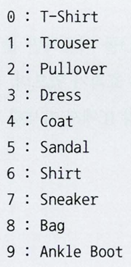

In [16]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision. transforms as transforms #데이터 전처리를 위해 사용하는 라이브러리
from torch.utils.data import Dataset, DataLoader

파이토치는 기본적으로 GPU 사용을 권장한다. 하지만 GPU가 내장되지 않은 환경에서도 파이토치를 정상적으로 실행하고 사용할 수 있다. GPU가 장착되어 있고, GPU를 사용하기 위한 설정이 되어 있다면 파이토치에서 자동으로 인식한다.

In [17]:
device = torch.device( "cuda:0" if torch.cuda.is_available() else "cpu" )

- GPU 사용

일반적으로 하나의 GPU를 사용할 때는 다음과 같은 코드를 이용한다.

device = torch.device( "cuda :0" if torch .cuda.is_available() else "cpu" )

model = Net( )

model.to(device)

하지만 사용하는 PC에서 다수의 GPU를 사용한다면 다음 코드와 같이 nn.DataParallel을 이용한다.

device = torch.device( "cuda" if torch.cuda.is_available() else "cpu" )

model = Net()

if torch.cuda .device_count() > 1:

model = nn.DataParallel(net)

model. to(device)

nn.DataParallel을 사용할 경우 배치 크기(batch size)가 알아서 각 GPU로 분배되는 방식으로 작동한다. 따라서 GPU 수만큼 배치 크기도 늘려 주어야 한다.




이번 예제에서 사용할 fashion_mnist 데이터셋은 토치비전으로 내려받을 수 있다.

In [18]:
train_dataset = torchvision.datasets.FashionMNIST( "../chap05/data", download=True, transform=transforms.Compose([transforms.ToTensor()] ))
test_dataset = torchvision.datasets.FashionMNIST( "../chap05/data", download=True, train=False, transform=transforms.Compose([transforms.ToTensor()]))

100%|██████████| 26.4M/26.4M [00:01<00:00, 18.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 305kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.58MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 22.9MB/s]


torchvision.datasets는 torch.utils.data.Dataset의 하위 클래스로 다양한 데이터셋(CIFAR, COCO, MNIST, ImageNet 등)을 포함한다. torchvision.datasets에서 사용하는 주요 파라미터는 다음과 같다.

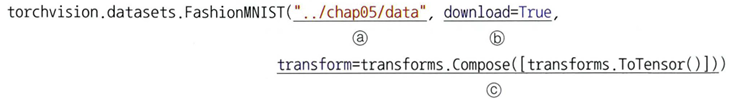

- a. 첫 번째 파라미터: FashionMNIST를 내려받을 위치를 지정한다.
- b. download: download를 True로 변경해주면 첫 번쨰 파라미터의 위치에 해당 데이터셋이 있는지 확인한 후 내려받는다.
- c. transform: 이미지를 텐서(0~1)로 변경한다.

다음은 fashion_mnist 데이터를 내려받은 결과이다. 내려받은 fashion_mnist 데이터셋을 확인하려면 ../chap05/data 폴더 하위에서 FashionMNIST 폴더를 확인하면 된다. 환경에 따라 내려받은 위치가 다를 수 있다.



내려받은 fashion_mnist 데이터를 메모리로 불러오기 위해 데이터로더에 전달한다.

In [19]:
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=100)

torch.utils.data.DataLoader()를 사용하여 원하는 크기의 배치 단위로 데이터를 불러오거나, 순서가 무작위로 섞이도록 할 수 있다. 데이터로더에서 사용하는 파라미터는 다음과 같다.

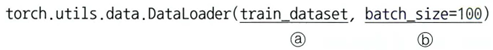

- a. 첫 번째 파라미터: 데이터를 불러올 데이터셋을 지정한다.
- b. batch_size: 데이터를 배치로 묶어준다. 여기에서는 batch_size=100으로 지정했기 때문에 100개 단위로 데이터를 묶어서 불러온다.

이제 예제에서 다루고 있는 이미지를 살펴보겠습니다. 먼저 20개의 이미지를 레이블 정보와 함께 출력합니다. 이때 레이블은  'T-Shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal',
'Shirt', 'Sneaker', 'Bag', 'Ankle Boot' 등 열 개의 클래스로 구성된다.


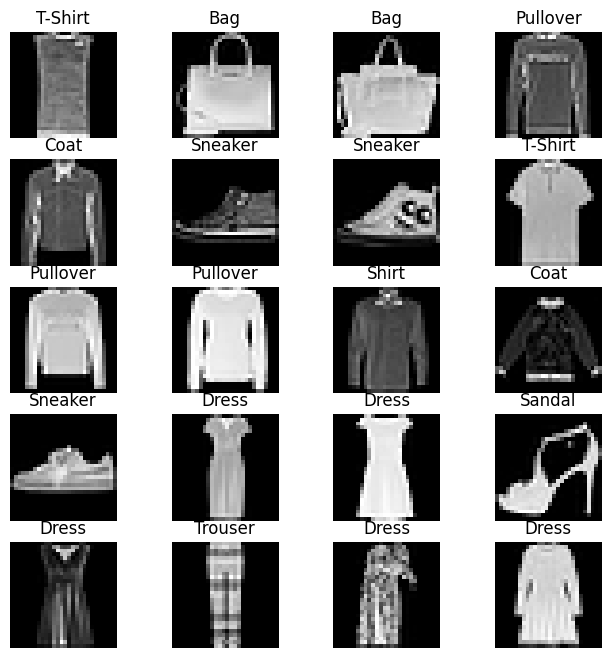

In [20]:
labels_map = {0 :  'T-Shirt' , 1 :  'Trouser' , 2 : 'Pullover' , 3 :  'Dress' , 4: 'Coat', 5 : 'Sandal' , 6 :'Shirt' , 7 : 'Sneaker' , 8 : 'Bag' , 9 : 'Ankle Boot' } #열 개의 클래스

fig = plt.figure( figsize=(8,8)); #출력할 이미지의 가로세로 길이로 단위는 inch
columns = 4;
rows = 5;
for i in range (1, columns*rows +1):
  img_xy = np. random. randint (len (train_dataset) );
  img = train_dataset[img_xy][0][ 0,:,:]
  fig .add_subplot(rows , columns , i )
  plt.title(labels_map [train_dataset[ img_xy ][1]])
  plt.axis( 'off')
  plt.imshow(img, cmap='gray' )
plt. show() #20개의 이미지 데이터를 시각적으로 표현

np.random은 무작위로 데이터를 생성할 때 사용한다. 또한, np.random.randint()는 이산형 분포를 갖는 데이터에서 무작위 표본을 추출할 때 사용한다. 따라서 random.radint(len(train_dataset)) 의미는 0~(train_dataset의 길이) 값을 갖는 분포에서 랜덤한 숫자 한 개를 생성하라는 의미이다. 참고로 random.radint와 유사하게 사용되는 random.rand와 random.randn을 예시로 살펴보겠다.


In [21]:
import numpy as np
np.random.randint(10)

6

In [22]:
np. random. randint(1,10)

5

In [23]:
np.random.rand(8)

array([0.54486096, 0.50608864, 0.44072143, 0.24512911, 0.10691505,
       0.34840571, 0.38354781, 0.9253762 ])

In [24]:
np.random.rand(4,2)

array([[0.86812408, 0.81531505],
       [0.57010024, 0.0248325 ],
       [0.57974652, 0.88337083],
       [0.9642985 , 0.14433331]])

In [25]:
np.random.randn(8)

array([-0.48119938, -0.41010882, -1.7935304 ,  1.28533126,  1.58337433,
       -0.99372713,  0.73155229,  0.10575289])

In [26]:
np.random.randn(4,2)

array([[-0.19633522,  0.52196941],
       [-0.70123695, -0.36878355],
       [ 0.83545745,  0.12135904],
       [ 1.25044807, -0.06845332]])

train_dataset을 이용한 3차원 배열을 생성한다.

In [27]:
import numpy as np
examp=np.arange(0,100,3)
examp.resize(6,4)
examp

array([[ 0,  3,  6,  9],
       [12, 15, 18, 21],
       [24, 27, 30, 33],
       [36, 39, 42, 45],
       [48, 51, 54, 57],
       [60, 63, 66, 69]])

In [28]:
examp[3]

array([36, 39, 42, 45])

In [29]:
examp[3,3]

np.int64(45)

In [30]:
examp[3][3]

np.int64(45)

In [31]:
examp=np.arange(0,500,3)
examp.resize(3,5,5)
examp

array([[[  0,   3,   6,   9,  12],
        [ 15,  18,  21,  24,  27],
        [ 30,  33,  36,  39,  42],
        [ 45,  48,  51,  54,  57],
        [ 60,  63,  66,  69,  72]],

       [[ 75,  78,  81,  84,  87],
        [ 90,  93,  96,  99, 102],
        [105, 108, 111, 114, 117],
        [120, 123, 126, 129, 132],
        [135, 138, 141, 144, 147]],

       [[150, 153, 156, 159, 162],
        [165, 168, 171, 174, 177],
        [180, 183, 186, 189, 192],
        [195, 198, 201, 204, 207],
        [210, 213, 216, 219, 222]]])

In [32]:
examp[2][0][3]

np.int64(159)

즉, examp2[2][0][3]과 같이 train_dataset[img_xy][0][0,:,:] 의미는 train_dataset에서 [img_xy][0][0,:,:]에 해당하는 요소 값을 가져오겠다는 의미로 이해하면 된다. 코드를 실행하면 다음 그림과 같이 20개의 이미지가 시각적으로 표현된다.(결과를 랜덤으로 보여 주기 때문에 책과 다를 수 있다.) 합성곱 신경망과 합성곱 신경망이 아닌 심층 신경망의 비교를 위해 먼저 심층 신경망을 생성한 후 학습시켜 본다. 즉, ConvNet이 적용되지 않은 네트워크를 먼저 만들어 본다.

In [33]:
class FashionDNN (nn.Module):
  def __init__(self):
    super(FashionDNN , self).__init__()
    self.fc1 = nn.Linear( in_features=784, out_features=256)
    self.drop = nn.Dropout(0.25)
    self.fc2 = nn.Linear(in_features=256, out_features=128)
    self.fc3 = nn.Linear(in_features=128, out_features=10)
  def forward (self,input_data):
    out = input_data.view (-1 , 784)
    out = F.relu(self.fc1(out))
    out = self.drop(out)
    out = F.relu(self.fc2(out))
    out = self.fc3(out)
    return out

 클래스(class) 형태의 모넬은 항상 torch.nn.Module을 상속받는다. __init__ ()은 객체가 갖는 속성 값을 초기화하는 역할을 하며 객체가 생성될 때 자동으로 호출된다. super(FashionDNN,self). __init__()은 nn.Module 클래스를 상속받겠다는 의미로 이해하면 된다.

- 객체

파이토치의 근간은 C++이다. 따라서 C++에서 사용하는 객체 지향 프로그램의 특징들을 파이토치에서도 사용하게 되는데, 대표적인 것이 객체라는 개념이다. 객체 지향 프로그램은 프로그래밍에서 필요한 데이터를 추상화하여 속성이나 행동, 동작, 특징 등을 객체로 만들고, 그 객체들이 서로 유기적으로 동작하도록 하는 프로그래밍 방법이다. 좀 더 쉽게 표현하면 클래스라는 붕어빵 틀에서 여러 개의 객체라는 붕어빵을 찍어 내는 것과 같다. 즉, 재사용성의 이유로 객체 지향 프로그래밍을 많이 사용하고 있다. 그리고 이때 객체란 메모리를 할당받아 프로그램에서 사용되는 모든 데이터를 의미하기 때문에 변수, 함수 등은 모두 객체라고 할 수 있다. 객체는 다음과 같은 방식으로 사용한다. 객체명=클래스명()

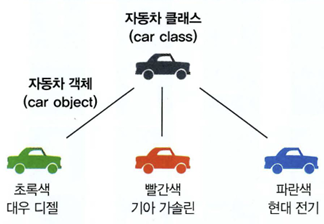

- 클래스와 함수

함수랑 하나의 특정 작업을 수행하기 위해 독립적으로 설계된 프로그램 코드이다. 함수의 호출은 특정 작업만 수행할 뿐 그 결괏값을 계속 사용하기 위해서는 반드시 어딘가에 따로 그 값을 저장해야만 한다. 즉, 함수를 포함한 프로그램 코드의 일부를 재사용하기 위해서는 해당 함수뿐만 아니라 데이터가 저장되는 변수까지도 한꺼번에 관리해야 한다. 이처럼 함수 뿐만 아니라 관련된 변수까지도 한꺼번에 묶어서 관리하고 재사용할 수 있게 해 주는 것이 클래스이다. 클래스와 함수의 차이를 코드로 살펴본다. 먼저 함수에 대한 예시이다.


In [35]:
def add(num1, num2):
  result = num1+num2
  return result

print(add(1,2))
print(add(2,3))

3
5


다음은 클래스에 대한 코드이다.

In [36]:
class Calc:
  def __init__(self):
    self.result=0

  def add(self,num1,num2):
    self.result=num1+num2
    return self.result

obj1=Calc()
obj2=Calc()

print(obj1.add(1, 2))
print(obj1. add(2, 3))
print('--------------------')
print (obj2.add(2, 2))
print(obj2.add(2, 3))

3
5
--------------------
4
5


결과로 볼 수 있듯이 두 개의 객체는 독립적으로 연산된다. 개별적 함수로 구현했다면 복잡했을 코드가 클래스 사용으로 간결해졌다.

nn은 딥러닝 모델(네트워크) 구성에 필요한 모듈이 모여 있는 패키지이며, Linear는 단순 선형 회귀 모델을 만들 때 사용한다. 이때 사용되는 파라미터는 다음과 같다.

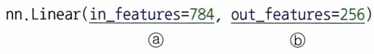

a. in_feaures: 입력의 크기

b. out_features: 출력의 크기

실제로 데이터 연산이 진행되는 forward() 부분에서는 첫 번째 파라미터 값만 넘겨주게 되며, 두 번째 파라미터에서 정의된 크기가 forward() 연산의 결과가 된다.

torch.nn.Dropout(p)는 p만큼의 비율로 텐서의 값이 0이 되고, 0이 되지 않는 값들은 기존 값에 (1/(1-p))만큼 곱해져 커진다. 예를 들어 p=0.3이라는 의미는 전체 값 중 0.3의 확률로 0이 된다는 것이며, 0이 되지 않는 0.7에 해당하는 값은 (1/(1-0.7))만큼 커진다.

forward() 함수는 모델이 학습 데이터를 입력받아서 순전파 학습을 진행시키며, 반드시 forward라는 이름의 함수여야 한다. 즉, forward()는 모델이 학습 데이터를 입력받아서 순전파 연산을 진행하는 함수에며, 객체를 데이터와 함꼐 호출하면 자동으로 실행된다. 이때 순전파 연산이란 H(x) 식에 입력 x로부터 예측된 y를 얻는 것이다.

파이토치에서 사용하는 뷰는 넘파이의 reshape과 같은 역할로 텐서의 크기를 변경해주는 역할을 한다. 따라서 input_data.view(-1,784)는 input_data를 (?,784)의 크기로 변경하라는 의미이다. 이때 첫번째 차원(-1)은 사용자가 잘 모르겠으니 파이토치에 맡기겠다는 의미이고, 두 번째 차원의 길이는 784를 가지도록 하라는 의미이다. 다시 말해 2차원 텐서로 변경하되 (?,784)의 크기로 변경하라는 의미이다.

활성화함수를 지정할 때는 다음 두 가지 방법이 가능하다.
- F.relu(): forward() 함수에서 정의
- nn.ReLU(): __init__() 함수에서 정의

활성화 함수 사용에 한정하여 이 둘 간의 차이는 간단히 사용하는 위치라고 할 수 있다. 하지만 근본적으로는 nn.functional.xx() (혹은 F.xx())와 nn.xx()는 사용 방법에 차이가 있다. 다음 코드를 통해 둘 간의 차이를 확인할 수 있다. 먼저 nn을 사용하는 코드는 다음과 같다.

In [37]:
import torch
import torch.nn as nn

inputs = torch .randn(64, 3, 244, 244)
conv = nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, padding=1)
outputs = conv(inputs)
layer = nn.Conv2d(1,1,3)

그리고 nn.functional을 사용하는 예시 코드는 다음과 같다.

In [38]:
import torch.nn.functional as F

inputs = torch.randn(64, 3, 244, 244)
weight = torch.randn(64, 3, 3, 3)
bias = torch.randn(64)
outputs = F.conv2d(inputs, weight , bias, padding=1)

nn.Conv2d에서 input_channel과 output_channel을 사용해서 연산했다면 functional.conv2d는 입력과 가중치 자체를 직접 넣어 준다. 이때 직접 넣어 준다는 의미는 가중치를 전달해야 할 때마다 가중치 값을 새로 정의해야 함을 의미한다. 그 외에 채워야 하는 파라미터들은 nn.Conv2d와 비슷하다.

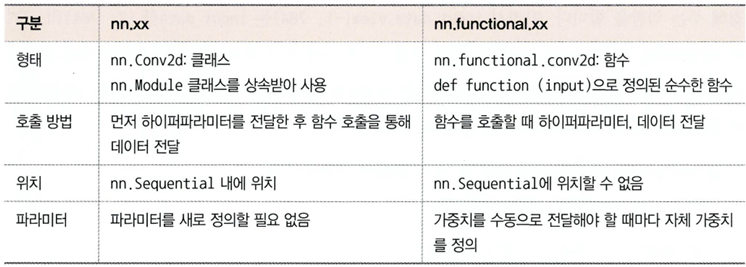

모델을 학습시키기 전에 손실 함수, 학습률, 옵티마이저에 대해 정의한다.

In [39]:
learning_rate = 0.001 ;
model = FashionDNN() ;
model.to(device)

criterion = nn.CrossEntropyLoss(); #분류 문제에서 사용하는 손실 함수
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


옵티마이저를 위한 경사 하강법은 Adam을 사용하며, 학습률을 의미하는 lr은 0.001을 사용한다는 의미이다. 앞 코드를 실행하면 앞에서 다음과 같이 심층 신경망 모델을 보여준다. 이제 심층 신경망에 데이터를 적용하여 모델을 학습시킨다.

In [43]:
num_epochs = 5
count = 0
loss_list=[]  #1
iteration_list=[]
accuracy_list=[]

predictions_list=[]
labels_list=[]

for epoch in range (num_epochs):
  for images, labels in train_loader: #2
    images, labels = images.to(device), labels.to(device) #3

    train = Variable(images.view(100, 1, 28, 28)) #4
    labels = Variable(labels)

    outputs = model(train) #학습 데이터를 모델에 적용
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss .backward()
    optimizer.step()
    count += 1

    if not (count % 50 ): #count를 50으로 나누었을 때 나머지가 0이 아니라면 실행
      total = 0
      correct = 0
      for images , labels in test_loader:
        images , labels = images.to(device), labels.to(device)
        labels_list.append(labels)
        test = Variable(images.view(100, 1, 28, 28))
        outputs = model(test)
        predictions = torch.max(outputs, 1)[1].to(device)
        predictions_list.append (predictions)
        correct += (predictions == labels).sum()
        total += len(labels)

      accuracy = correct * 100 / total  #5
      loss_list. append (loss. data)  #1'
      iteration_list.append(count)
      accuracy_list.append (accuracy)

    if not (count % 500):
      print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count,loss.data,accuracy))

Iteration: 500, Loss: 0.6347031593322754, Accuracy: 83.1500015258789%
Iteration: 1000, Loss: 0.4994189143180847, Accuracy: 84.5999984741211%
Iteration: 1500, Loss: 0.3679673671722412, Accuracy: 84.55999755859375%
Iteration: 2000, Loss: 0.42061135172843933, Accuracy: 85.1500015258789%
Iteration: 2500, Loss: 0.23062272369861603, Accuracy: 85.8499984741211%
Iteration: 3000, Loss: 0.26792776584625244, Accuracy: 86.80000305175781%


- 1,1' 일반적으로 배열이나 행렬과 같은 리스트를 사용하는 방법은 다음과 같다.
  + 1과 같이 비어있는 배열이나 행렬을 만든다.
  + 1'처럼 append 메서드를 이용하여 데이터를 하나씩 추가한다.

- 2 for 구문을 사용하여 레코드(행, 가로줄)를 하나씩 가져온다, 이때 for x,y in train: 과 같이 in 앞에 변수를 두 개 지정해주면 레코드에서 요소 두 개를 꺼내 오겠다는 의미이다.

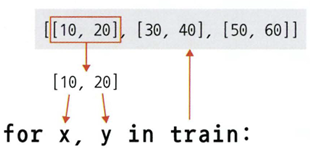

- 3 모델이 데이터를 처리하기 위해서는 모델과 데이터가 동일한 장치(CPU 또는 GPU)에 있어야 한다. 코드 5-7에서 model.to(device)가 GPU를 사용했다면, images.to(device), labels.to(device)도 GPU에서 처리되어야 한다. 참고로 CPU에서 처리된 데이터를 GPU 모델에 적용하거나 그 반대의 경우 런타임 오류가 발생한다.

- 4 Autograd는 자동 미분을 수행하는 파이토치의 핵심 패키지로, 자동 미분에 대한 값을 저장하기 위해 테이프를 사용한다. 순전파 단계에서 테이프는 수행하는 모든 연산을 저장한다. 그리고 역전파 단계에서 저장된 값들을 거내서 사용한다. 즉, Autograd는 Variable을 사용해서 역전파를 위한 미분 값을 자동으로 계산해준다. 따라서 자동 미분을 계산하기 위해서는 torch.autograd 패키지 안에 있는 Variable을 이용해야 동작한다.

- 5 분류 문제에 대한 정확도는 전체 예측에 대한 정확한 예측의 비율로 표현할 수 있으며, 코드는 다음과 같다.

classification accuracy = correct predictions / total predictions

이때 결과에 100을 곱하여 백분율로 표시되는 코드는 다음과 같다.

classification accuracy = correct predictions / total predictions * 100

또한, 분류 문제에 대한 정확도는 다음과 같이 값을 반전시켜 오분류율 또는 오류율로 표현할 수 있다.

error rate = (1 - (correct predictions / total predictions)) * 100

분류 문제에서 클래스가 세 개 이상일 때는 다음과 같은 사항에 주의해야 한다.
 + 정확도가 80% 이상이었다고 한다. 하지만 80%라는 값이 모든 클래스가 동등하게 고려된 것인지, 특정 클래스의 분류가 높았던 것인지에 대해 알 수 없음에 유의해야 한다.
 + 정확도가 90% 이상이었다고 한다. 하지만 100개의 데이터 중 90개가 하나의 클래스에 속할 경우 90%의 정확도는 높다고 할 수 없다. 즉, 모든 데이터를 특정 클래스에 속한다고 예측해도 90%의 예측 결과가 나오기 때문에 데이터 특성에 따라 정확도를 잘 관측해야 한다. 코드를 실행하면 위와 같이 모델 훈련 결과가 출력된다. 최종적으로 정확도가 86%로 높은 수치를 보여준다. 심층 신경망에 대한 모델 생성과 성능을 평가해보았다면, 이제 합성곱 신경망을 생성해본다.

In [44]:
class FashionCNN (nn .Module):
  def __init__ (self):
    super(FashionCNN, self). __init__()
    self.layer1 = nn.Sequential( #1
        nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1), #2
        nn. BatchNorm2d (32) , #3
        nn.ReLU() ,
        nn. MaxPool2d(kernel_size=2, stride=2) #4
    )
    self.layer2 = nn.Sequential(
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self. fc1 = nn.Linear(in_features=64*6*6, out_features=600) #5
    self.drop = nn.Dropout2d(0.25)
    self.fc2 = nn .Linear(in_features=600, out_features=120)
    self.fc3 = nn.Linear(in_features=120, out_features=10)

  def forward(self, x):
    out = self.layer1(x)
    out = self.layer2(out)
    out = out.view(out.size(0), -1) #6
    out = self.fc1(out)
    out = self.drop(out)
    out = self.fc2(out)
    out = self.fc3(out)
    return out

- 1 nn.Sequential을 사용하면 __init__()에서 사용할 네트워크 모델들을 정의해 줄 뿐만 아니라, forward() 함수에서 구현될 순전파를 계층 형태로 좀 더 가독성이 뛰어난 코드로 작성할 수 있다. 즉, nn.Sequential은 계층을 차례로 쌓을 수 있도록 Wx+b와 같은 수식과 활성화 함수를 연결해주는 역할을 한다. 특히 데이터가 각 계층을 순차적으로 지나갈 때 사용하면 좋은 방법이다. 정리하면 nn.Sequential은 여러 개의 계층을 하나의 컨테이너에 구현하는 방법이라고 생각하면 된다.
- 2 합성곱층은 합성곱 연산을 통해서 이미지의 특징을 추출한다. 합성곱이랑 커널(또는 필터)이라는 nxm 크기의 행렬이 높이x너비 크기의 이미지를 처음부터 끝까지 훑으면서 각 원소 값끼리 곱한 후 모두 더한 값을 출력한다. 커널은 일반적으로 3x3이나 5x5를 사용하며 파라미터는 다음과 같다.

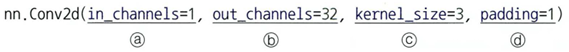

 + a in_channels: 입력 채널의 수를 의미한다, 흑백 이미지는 1, RGB 값을 가진 이미지는 3을 가진 경우가 많다. 2D 합성곱층에 이미지를 적용한다고 가정해본다, 흑백 이미지의 경우 이미지 데이터는 w x h 형태의 행렬로 표현된다(이때 w는 이미지의 너비, h는 이미지의 높이가 된다). 이 번에는 컬러 이미지를 가정해본다. 컬러 이미지는 일반적으로 Red, Green, Blue라는 세 개의 채널을 가지고 있다. 이때 컬러 이미지는 w x h x c 형태의 행렬로 표현될 수 있다(c는 채널 수를 의미한다). 3차원으로 생각하면 채널은 결국 깊이를 의미한다고 할 수 있다.

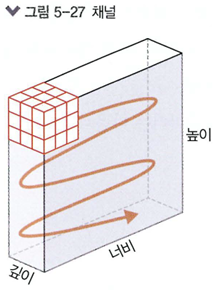

 + b out_channels: 출력 채널의 수를 의미한다.
 + c kernel_size: 커널 크기를 의미하며 논문에 따라 필터라고도 한다. 커널은 이미지 특징을 찾아내기 위한 공용 파라미터이며, CNN에서 학습 대상은 필터 파라미터가 된다. 커널은 입력 데이터를 스트라이드 간격으로 순환하면서 합성곱을 계산한다. 참고로 kernel_size=3이라고 했을 때, 커널의 크기는 (3,3)으로 정사각형을 의미하며 직사각형을 사용하고 싶다면 (3,5)처럼 지정한다.
 + d padding: 패딩 크기를 의미하는 것으로 출력 크기를 조정하기 위해 입력 데이터 주위에 0을 채운다, 패딩 값이 클수록 출력 크기도 커진다.

- 3 BatchNorm2d는 학습 과정에서 각 배치 단위별로 데이터가 다양한 분포를 가지더라도 평균과 분산을 이용하여 정규화하는 것을 의미한다. 다음 그림을 보면 배치 단위나 계층에 따라 입력 값의 분포가 모두 다르지만 정규화를 통해 분포를 가우시안 형태로 만든다. 그러면 평균은 0, 표준편차는 1로 데이터의 분포가 조정된다.

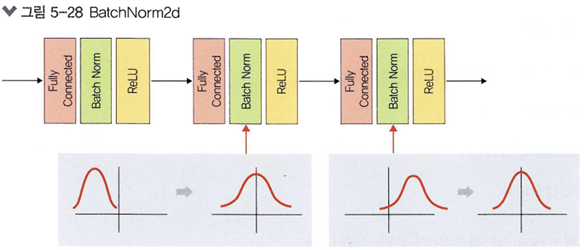

- 4 MaxPool2d는 이미지 크기를 축소시키는 용도로 사용한다. 풀링 계층은 합성곱층의 출력 데이터를 입력으로 받아서 출력 데이터의 크기를 줄이거나 특정 데이터를 강조하는 용도로 사용된다. 풀링 계층을 처리하는 방법으로는 최대 풀링과 평균 풀링, 최소 풀링이 있으며, 이때 사용하는 파라미터는 다음과 같다.

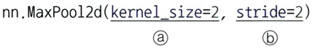

 + a. kernel_size: m x n 행렬로 구성된 가중치
 + b. stride: 입력 데이터에 커널(필터)을 적용할 때 이동할 간격을 의미하는데, 스트라이드 값이 커지면 출력 크기는 작아진다.

- 5 클래스를 분류하기 위해서는 이미지 형태의 데이터를 배열 형태로 변환하여 작업해야 합니다. 이때 Conv2d에서 사용하는 하이퍼파라미터 값들에 따라 출력 크기가 달라진다. 즉, 패딩과 스트라이드의 값에 따라 출력 크기가 달라진다. 이렇게 줄어든 출력 크기는 최종적으로 분류를 담당하는 완전연결층으로 전달된다.


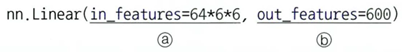

 + a in_features: 입력 데이터의 크기를 의미한다. 중요한 것은 이전까지 수행했던 Conv2d, MaxPool2d는 이미지 데이터를 입력으로 받아 처리했다. 하지만 그 출력 결과를 완전연결층으로 보내기 위해서는 1차원으로 변경해주어야 하는데, 공식은 다음과 같다. 공식은 Conv2d와 MaxPool2d가 다르기 때문에 매 계층을 따라가면서 계산해보는 것이 좋다.





- Conv2d 계층에서의 출력 크기를 구하는 공식
 + 출력 크기 = (W-F+2P)/S+1
  * W: 입력 데이터의 크기(input_volume_size)
  * F: 커널 크기(kernel_size)
  * P: 패딩 크기(padding_size)
  * S: 스트라이드(strides)

예를 들어 첫 번째 Conv2d 계층은 다음과 같다.

nn.Conv2d( in_channels=1 , out_channels=32, kernel_size=3, padding=1)

따라서 출력 크기는 다음과 같이 계산할 수 있다.

(28 - 3 + (2*1))/1 + 1 = 28

Fashion_mnist의 입력 크기는 (28x28)로, 가로와 세로가 모두 동일하므로 28을 사용하며, stride가 명시되어 있지 않다면 stride 기본값은 (1,1)이다. 계산 결과를 적용하면 출력의 형태는 [32,28,28]이 된다.

- MaxPool2d 계층에서의 출력 크기 구하는 공식
 + 출력 크기 = IF/F
  * IF: 입력 필터의 크기(input_filter_size, 또한 바로 앞의 Conv2d의 출력 크기이기도 한다.)
  * F: 커널 크기(kernel_size)

예를 들어 첫 번째 MaxPool2d 계층은 다음과 같다.

nn.MaxPool2d(kernel_size=2, stride=2)

따라서 출력 크기는 다음과 같이 계산할 수 있다.

784/2=392 (784는 첫 번째 Conv2d에서 계산한 결과이다)

계산 결과를 적용하면 출력의 형태는 [32, 392, 392]가 된다. 그리고 가장 앞의 32는 바로 앞 Conv2d 계층의 out_channels이다.


- b out_features: 출력 데이터의 크기를 의미한다.
- 6 합성곱층에서 완전연결층으로 변경되기 때문에 데이터의 형태를 1차원으로 바꾸어준다.

이때 out.size(0)은 결국 100을 의미한다, 따라서 (100,?) 크기의 텐서로 변경하겠다는 의미이다. out.view(out.size(0),-1)에서 '-1'은 행의 수는 정확히 알고 있지만 열의 수는 알지 못할 때 사용한다. 이번에는 합성곱 네트워크를 사용하기 위한 파라미터를 정의한다.

In [45]:
learning_rate=0.001;
model=FashionCNN();
model.to(device)

criterion = nn.CrossEntropyLoss();
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


모든 준비가 완료되었기 때문에 학습 데이터를 이용하여 모델을 학습시킨다.

In [46]:
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range (num_epochs):
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    train = Variable(images.view(100, 1, 28, 28))
    labels = Variable(labels)

    outputs = model(train)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not (count % 50):
      tota1 = 0
      correct = 0
      for images, labels in test_loader:
        images, labels = images.to(device) , labels .to(device)
        labels_list.append (labels)
        test = Variable(images.view(100, 1, 28, 28))
        outputs = model(test)
        predictions = torch.max(outputs, 1)[1].to(device)
        predictions_list.append (predictions)
        correct += (predictions == labels).sum()
        tota1 += len(labels)

      accuracy = correct * 100 / total
      loss_list.append (loss.data)
      iteration_list.append(count)
      accuracy_list.append (accuracy)

    if not (count % 500):
      print("Iteration: {}, Loss: {}, Accuracy: {}%".format(count, loss.data, accuracy))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


Iteration: 500, Loss: 0.47116249799728394, Accuracy: 87.48999786376953%
Iteration: 1000, Loss: 0.29264548420906067, Accuracy: 88.61000061035156%
Iteration: 1500, Loss: 0.32602962851524353, Accuracy: 88.8499984741211%
Iteration: 2000, Loss: 0.19354824721813202, Accuracy: 89.7699966430664%
Iteration: 2500, Loss: 0.15885449945926666, Accuracy: 90.01000213623047%
Iteration: 3000, Loss: 0.18924947082996368, Accuracy: 90.30000305175781%


심층 신경망과 비교하여 정확도가 약간 높다. 심층 신경망과 별 차이가 없기 때문에 좀 더 간단한 심층 신경망만 사용해도 무난할 것 같지만 실제로 이미지 데이터가 많아지면 단순 심층 신경망으로는 정확한 특성 추출 및 분류가 불가능하므로 합성곱 신경망을 생성할 수 있도록 학습해야 한다.